In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re, string
from wget import download

In [2]:
RAW_DATA = './data/raw'
TRAIN_DATA = './data/train'
TEST_DATA = './data/test'
TEST_SIZE = 0.3

In [3]:
from subprocess import Popen, PIPE, STDOUT
from IPython.core.magic import register_line_magic

@register_line_magic
def runshell(command):
    with Popen(
        command, stdout=PIPE, shell=True, stderr=STDOUT, bufsize=1, close_fds=True
    ) as process:
        for line in iter(process.stdout.readline, b""):
            print(line.decode("utf-8"), end='')

In [4]:
# Convert this cell to 'Code' to build mltextclassifier.exe
%runshell cd ..\.. && mkdir build && cd build && cmake .. >> buildlog.txt 2>&1
%runshell cd ..\..\build && cmake --build . --config Release >> buildlog.txt 2>&1
%runshell copy ..\..\build\Release\mltextclassifier.exe .

c:\users\rajas\appdata\local\programs\python\python39\lib\subprocess.py:937: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)


A subdirectory or file build already exists.
        1 file(s) copied.


In [5]:
# as dataset is big to store in repo we will download dataset from original site
# however the dataset is present on #https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification?select=WELFake_Dataset.csv
# which can be renamed to data.csv if in case below download link is broken
download('https://zenodo.org/record/4561253/files/WELFake_Dataset.csv?download=1', RAW_DATA + '/data.csv')

100% [......................................................................] 245086152 / 245086152

'./data/raw/data.csv'

In [6]:
#https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification?select=WELFake_Dataset.csv
with open(RAW_DATA + '/data.csv', errors='ignore') as f:
    df = pd.read_csv(f)

In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.dropna(axis=0, inplace=True)
df.drop_duplicates(inplace=True)
df['text'] = df['title'] + df['text']
df.drop(columns=['title'], inplace=True)
df = df.sample(frac=1, random_state=42)
df

,text,label
71361,Donald Trump Responds To Mockery Over Fake Sw...,1
11496,TweetwaveThis time it's true no pantsTweetwave...,1
20292,Rubio says prospect of Trump president is 'wor...,0
38855,Trump lifts Cyber Command status to boost cybe...,0
20416,The 7 Biggest Republican Lies About The Econo...,1
...,...,...
71433,More than half of Britons now want to stay in ...,0
41294,"Bill And Hillary Clinton, Inc.: For Sale At Th...",1
869,"Orlando Gunman Was Shot at Least 8 Times, Auto...",0
16332,The Lethal Gaps in How the Supreme Court Handl...,0


In [8]:
def clean_text(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans(' ', ' ', string.punctuation))
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    return text
    
df['text'] = df['text'].apply(clean_text)

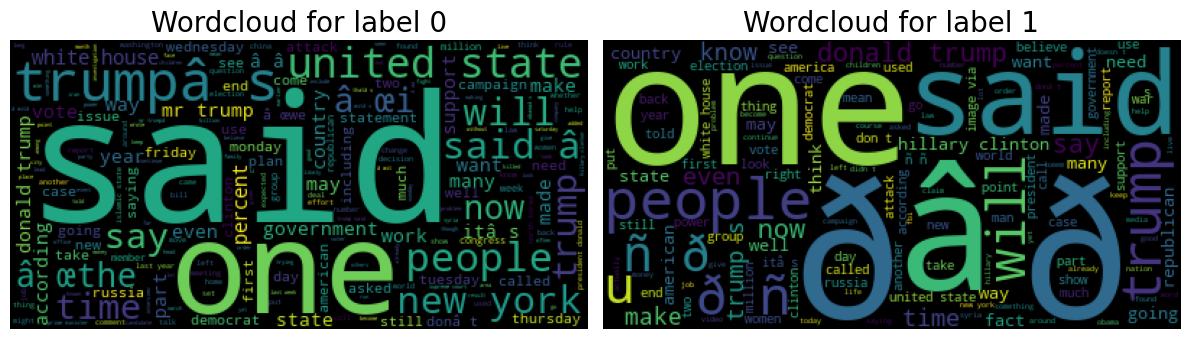

In [9]:
text_0 = ' '.join(df.loc[df.label == 0]['text'])
text_1 = ' '.join(df.loc[df.label == 1]['text'])

wordcloud_0 = WordCloud().generate(text_0)
wordcloud_1 = WordCloud().generate(text_1)

fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1.imshow(wordcloud_0)
ax1.axis("off")
ax1.set_title("Wordcloud for label 0",fontsize=20)

ax2.imshow(wordcloud_1)
ax2.axis("off")
ax2.set_title("Wordcloud for label 1",fontsize=20)

plt.tight_layout()
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], stratify=df['label'], 
                                                    test_size=TEST_SIZE, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [11]:
df_train.shape[0], df_test.shape[0]

(44184, 18937)

In [12]:
def save_data(df, rootdir):
    with open(rootdir + '/features.txt', 'wt', errors='ignore') as feat_fh, \
        open(rootdir + '/labels.txt', 'wt', errors='ignore') as labl_fh:
        for idx, row in df.iterrows():
            lb = str(row['label']) + '\n'
            ft = row['text'].lower() + '\n'
            labl_fh.write(lb)
            feat_fh.write(ft)

In [13]:
save_data(df_train, TRAIN_DATA)
save_data(df_test, TEST_DATA)
df_test.to_csv(TEST_DATA + '/data_test.csv', index=False)

In [14]:
%%time
%runshell mltextclassifier.exe f 1 1 model\model_CounterVectorizer_NaiveBayesClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,smoothing_param_m=1.0,smoothing_param_p=0.5

c:\users\rajas\appdata\local\programs\python\python39\lib\subprocess.py:937: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)


Training
minfrequency = 2
smoothing_param_m = 1
smoothing_param_p = 0.5
No of Rare Words = 220099
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % 

In [15]:
%%time
%runshell mltextclassifier.exe f 2 1 model\model_TfidfVectorizer_NaiveBayesClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,smoothing_param_m=1.0,smoothing_param_p=0.5

Training
minfrequency = 2
smoothing_param_m = 1
smoothing_param_p = 0.5
No of Rare Words = 220099
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 %

In [16]:
%%time
%runshell mltextclassifier.exe f 1 2 model\model_CounterVectorizer_LogisticRegressionClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 220099
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done

In [17]:
%%time
%runshell mltextclassifier.exe f 2 2 model\model_TfidfVectorizer_LogisticRegressionClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 220099
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % don

In [18]:
%%time
%runshell mltextclassifier.exe f 1 3 model\model_CounterVectorizer_SVCClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 220099
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done

In [19]:
%%time
%runshell mltextclassifier.exe f 2 3 model\model_TfidfVectorizer_SVCClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 220099
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % don

In [20]:
%%time
%runshell mltextclassifier.exe f 1 5 model\model_CounterVectorizer_RandomForestClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,num_trees=50,max_depth=5

Training
minfrequency = 2
num_trees = 50
max_depth = 5
No of Rare Words = 220099
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % done
90

In [21]:
%%time
%runshell mltextclassifier.exe f 2 5 model\model_TfidfVectorizer_RandomForestClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,num_trees=50,max_depth=5

Training
minfrequency = 2
num_trees = 50
max_depth = 5
No of Rare Words = 220099
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % done
90 % done
9

In [22]:
%%time
%runshell mltextclassifier.exe f 1 6 model\model_CounterVectorizer_GradientBoostingClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,n_trees=50,max_depth=5,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
n_trees = 50
max_depth = 5
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 220099
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 

In [23]:
%%time
%runshell mltextclassifier.exe f 2 6 model\model_TfidfVectorizer_GradientBoostingClassifier.dat data\train\features.txt data\train\labels.txt 1.0 minfrequency=2,n_trees=50,max_depth=5,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
n_trees = 50
max_depth = 5
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 220099
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83